In [4]:
import pandas as pd

# Read the CSV file directly into a DataFrame
df = pd.read_csv('online_retail_II.csv', encoding='ISO-8859-1') 
# encoding is often needed for this dataset

print(df.shape)
print(df.info())
print(df.head())

(1067371, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     212

In [5]:
# 1. Drop rows with no Customer ID (can't attribute to a customer for RFM)
df = df.dropna(subset=['Customer ID'])

# 2. Separate cancelled orders (Invoice starting with 'C') into their own table
df['Invoice'] = df['Invoice'].astype(str)
returns = df[df['Invoice'].str.startswith('C')].copy()
df = df[~df['Invoice'].str.startswith('C')].copy()

# 3. Remove noise: zero/negative price or quantity (shouldn't exist post-cancellation removal, but double check)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# 4. Convert InvoiceDate to real datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Cleaned shape:", df.shape)
print("Returns shape:", returns.shape)
print(df.isnull().sum())

Cleaned shape: (805549, 8)
Returns shape: (18744, 8)
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [6]:
# Revenue per line item
df['TotalPrice'] = df['Quantity'] * df['Price']

# Time-based features for trend analysis
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['Weekday'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

print(df[['InvoiceDate', 'Month', 'Weekday', 'Hour', 'TotalPrice']].head())
print(df['TotalPrice'].describe())

          InvoiceDate    Month  Weekday  Hour  TotalPrice
0 2009-12-01 07:45:00  2009-12  Tuesday     7        83.4
1 2009-12-01 07:45:00  2009-12  Tuesday     7        81.0
2 2009-12-01 07:45:00  2009-12  Tuesday     7        81.0
3 2009-12-01 07:45:00  2009-12  Tuesday     7       100.8
4 2009-12-01 07:45:00  2009-12  Tuesday     7        30.0
count    805549.000000
mean         22.026505
std         224.041928
min           0.001000
25%           4.950000
50%          11.850000
75%          19.500000
max      168469.600000
Name: TotalPrice, dtype: float64


In [7]:
# Peek at the biggest outliers
df.nlargest(10, 'TotalPrice')[['Invoice', 'Description', 'Quantity', 'Price', 'TotalPrice', 'Customer ID']]

,Invoice,Description,Quantity,Price,TotalPrice,Customer ID
1065882,581483,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0
587080,541431,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0
748132,556444,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,15098.0
432176,530715,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,1.69,15818.40,15838.0
135013,502263,Manual,1,10953.50,10953.50,12918.0
358639,524159,Manual,1,10468.80,10468.80,14063.0
74356,496115,Manual,1,8985.60,8985.60,17949.0
228042,511465,PINK PAPER PARASOL,3500,2.55,8925.00,18008.0
698843,551697,POSTAGE,1,8142.75,8142.75,16029.0
873786,567423,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,17450.0


In [8]:
# Check what non-product StockCodes exist
non_product_codes = ['POST', 'DOT', 'M', 'BANK CHARGES', 'C2', 'PADS', 'AMAZONFEE']
print(df[df['StockCode'].isin(non_product_codes)]['Description'].unique())

# Create a clean product-only view for product-level analysis
df_products = df[~df['StockCode'].isin(non_product_codes)].copy()

print("Full data:", df.shape)
print("Product-only data:", df_products.shape)

['POSTAGE' 'CARRIAGE' 'Manual' ' Bank Charges'
 'PADS TO MATCH ALL CUSHIONS' 'Bank Charges' 'DOTCOM POSTAGE']
Full data: (805549, 12)
Product-only data: (802684, 12)


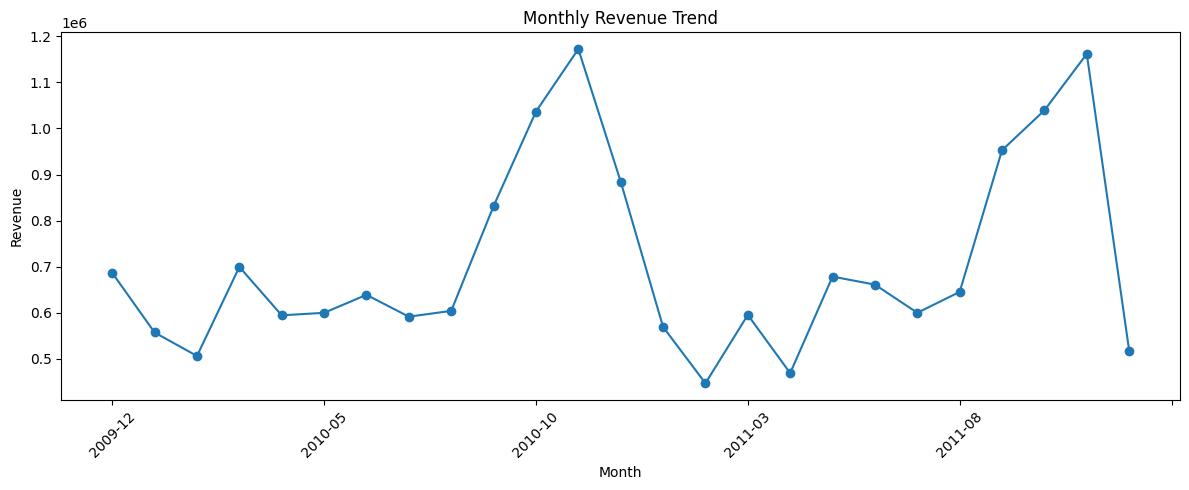

Description
REGENCY CAKESTAND 3 TIER              286486.30
WHITE HANGING HEART T-LIGHT HOLDER    252072.46
PAPER CRAFT , LITTLE BIRDIE           168469.60
JUMBO BAG RED RETROSPOT               136980.08
ASSORTED COLOUR BIRD ORNAMENT         127074.17
PARTY BUNTING                         103880.23
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         79594.33
CHILLI LIGHTS                          72860.14
BLACK RECORD COVER FRAME               67209.44
Name: TotalPrice, dtype: float64
Country
EIRE           621631.110
Netherlands    554232.340
Germany        431262.461
France         355257.470
Australia      169968.110
Spain          109178.530
Switzerland    100365.340
Sweden          91549.720
Denmark         69862.190
Belgium         65753.420
Name: TotalPrice, dtype: float64


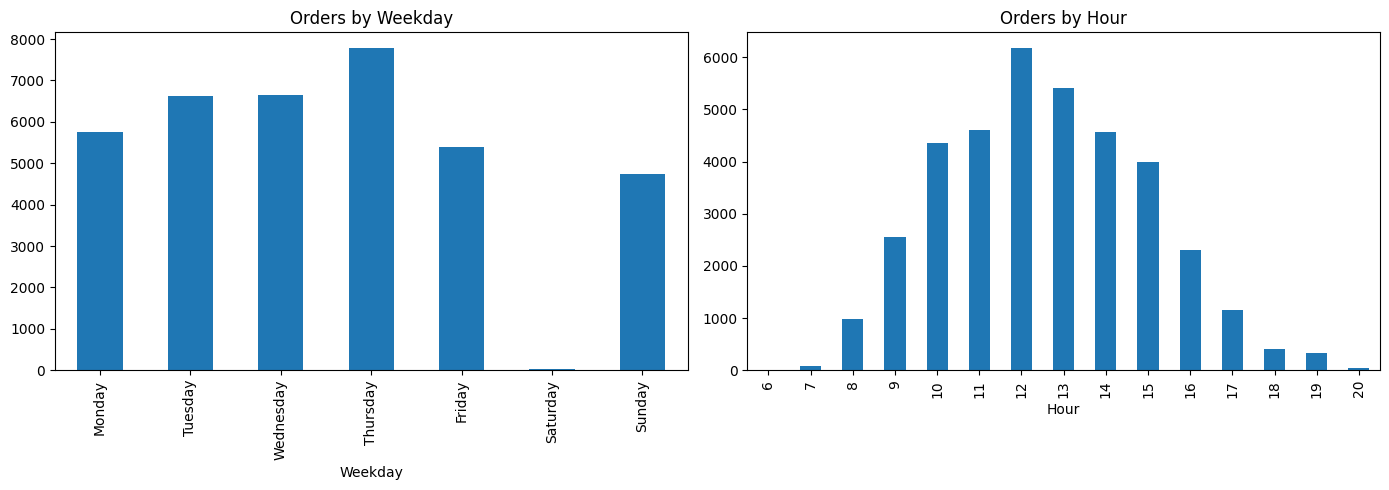

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Monthly revenue trend (use full df — includes postage/manual so totals are accurate)
monthly_revenue = df.groupby('Month')['TotalPrice'].sum()
monthly_revenue.index = monthly_revenue.index.astype(str)  # Period -> string for plotting

plt.figure(figsize=(12,5))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Top 10 products by revenue (use df_products — excludes postage/manual junk)
top_products = df_products.groupby('Description')['TotalPrice'].sum().nlargest(10)
print(top_products)

# 3. Revenue by country, excluding UK since it dwarfs everything else
country_revenue = df[df['Country'] != 'United Kingdom'].groupby('Country')['TotalPrice'].sum().nlargest(10)
print(country_revenue)

# 4. Order volume by weekday and hour (peak shopping time)
weekday_orders = df.groupby('Weekday')['Invoice'].nunique().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
hourly_orders = df.groupby('Hour')['Invoice'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14,5))
weekday_orders.plot(kind='bar', ax=axes[0], title='Orders by Weekday')
hourly_orders.plot(kind='bar', ax=axes[1], title='Orders by Hour')
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

# Snapshot date = one day after the last transaction, so "Recency" is relative to "today"
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(rfm.describe())

        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    3018.616737
std     1715.572666   209.338707    13.009406   14737.731040
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     348.762500
50%    15314.500000    96.000000     3.000000     898.915000
75%    16797.750000   380.000000     7.000000    2307.090000
max    18287.000000   739.000000   398.000000  608821.650000


In [11]:
# Recency: lower is better, so we reverse the labels (5 = most recent)
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)

# Frequency: higher is better, but many customers share the same low values (ties),
# so we rank first to avoid qcut errors on duplicate bin edges
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

# Monetary: higher is better
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print(rfm[['Customer ID','Recency','Frequency','Monetary','R_score','F_score','M_score','RFM_Score']].head(10))

   Customer ID  Recency  Frequency  Monetary  R_score  F_score  M_score  \
0      12346.0      326         12  77556.46        2        5        5   
1      12347.0        2          8   5633.32        5        4        5   
2      12348.0       75          5   2019.40        3        4        4   
3      12349.0       19          4   4428.69        5        3        5   
4      12350.0      310          1    334.40        2        1        2   
5      12351.0      375          1    300.93        2        1        2   
6      12352.0       36         10   2849.84        4        5        4   
7      12353.0      204          2    406.76        2        2        2   
8      12354.0      232          1   1079.40        2        1        3   
9      12355.0      214          2    947.61        2        2        3   

   RFM_Score  
0         12  
1         14  
2         11  
3         13  
4          5  
5          5  
6         13  
7          6  
8          6  
9          7  


In [12]:
def segment_customer(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 4 and row['F_score'] <= 2:
        return 'New/Promising'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'Lost/Churned'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print(rfm['Segment'].value_counts())
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1))

Segment
Lost/Churned       1523
Loyal Customers    1403
Champions          1300
At Risk             824
New/Promising       443
Needs Attention     385
Name: count, dtype: int64
                 Recency  Frequency  Monetary
Segment                                      
At Risk            369.1        4.9    1983.0
Champions           20.0       17.1    9329.3
Lost/Churned       459.3        1.3     438.0
Loyal Customers     71.4        5.4    1934.4
Needs Attention    107.1        1.4     534.1
New/Promising       28.1        1.5     890.8


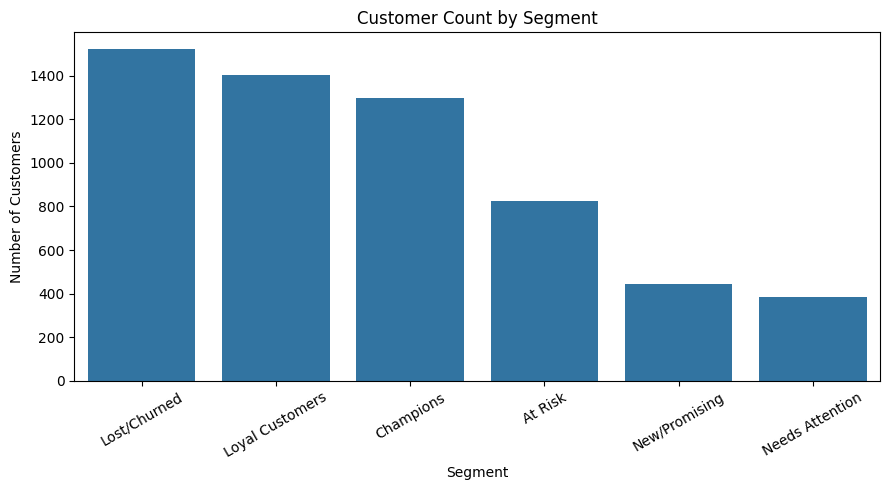

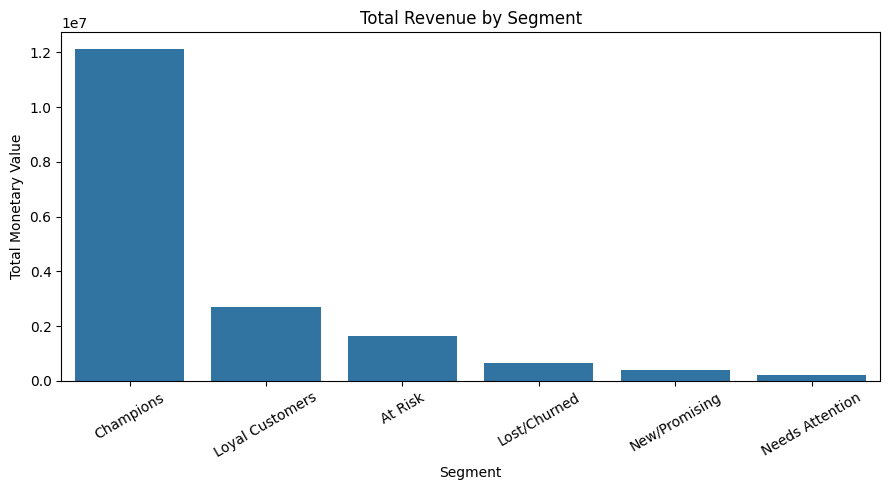

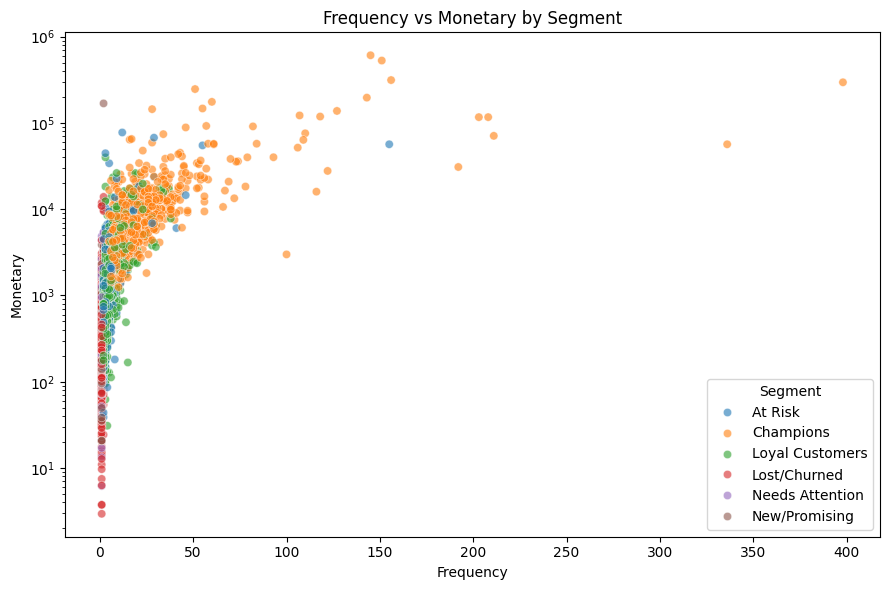

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Segment size (bar chart)
plt.figure(figsize=(9,5))
segment_order = rfm['Segment'].value_counts().index
sns.barplot(x=rfm['Segment'].value_counts().index, y=rfm['Segment'].value_counts().values, order=segment_order)
plt.title('Customer Count by Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 2. Segment value (which segments actually drive revenue)
segment_value = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
plt.figure(figsize=(9,5))
sns.barplot(x=segment_value.index, y=segment_value.values, order=segment_value.index)
plt.title('Total Revenue by Segment')
plt.ylabel('Total Monetary Value')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 3. Scatter: Frequency vs Monetary, colored by segment (log scale since Monetary is skewed)
plt.figure(figsize=(9,6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Segment', alpha=0.6)
plt.yscale('log')
plt.title('Frequency vs Monetary by Segment')
plt.tight_layout()
plt.show()

In [14]:
total_revenue = rfm['Monetary'].sum()
segment_pct = (segment_value / total_revenue * 100).round(1)
print(segment_pct)

Segment
Champions          68.4
Loyal Customers    15.3
At Risk             9.2
Lost/Churned        3.8
New/Promising       2.2
Needs Attention     1.2
Name: Monetary, dtype: float64


In [15]:
# 1. Cleaned transaction-level data (for Power BI / SQL import)
df.to_csv('cleaned_transactions.csv', index=False)

# 2. RFM + segment table (customer-level summary)
rfm.to_csv('customer_rfm_segments.csv', index=False)

# 3. Monthly revenue summary (handy pre-aggregated table for dashboards)
monthly_summary = df.groupby('Month').agg(
    Revenue=('TotalPrice', 'sum'),
    Orders=('Invoice', 'nunique'),
    Customers=('Customer ID', 'nunique')
).reset_index()
monthly_summary['Month'] = monthly_summary['Month'].astype(str)
monthly_summary.to_csv('monthly_summary.csv', index=False)

print("Exported 3 files:")
print("- cleaned_transactions.csv:", df.shape)
print("- customer_rfm_segments.csv:", rfm.shape)
print("- monthly_summary.csv:", monthly_summary.shape)

Exported 3 files:
- cleaned_transactions.csv: (805549, 12)
- customer_rfm_segments.csv: (5878, 9)
- monthly_summary.csv: (25, 4)


In [ ]:
# Instead of loading full cleaned_transactions.csv in the app, export smaller derived tables:
product_revenue = df.groupby('Description')['TotalPrice'].sum().reset_index()
product_revenue.to_csv('product_revenue_summary.csv', index=False)  # ~4000 rows, tiny

country_monthly = df.groupby(['Country', df['InvoiceDate'].dt.to_period('M').astype(str)])['TotalPrice'].sum().reset_index()
country_monthly.to_csv('country_monthly_summary.csv', index=False)  # small